# Stochastic Epidemic Models: SIR and SEIR

These are continuous-time compartmental epidemic models on a closed population. Every individual is in one **compartment** at a time, and moves between them at random:

- **SIR**: **S**usceptible -> **I**nfectious -> **R**ecovered.
- **SEIR**: **S**usceptible -> **E**xposed (infected, not yet infectious) -> **I**nfectious -> **R**ecovered.

Each draw is a sample path -- the compartment counts as a function of continuous time -- simulated until the epidemic ends (no one infectious left). Calling a path at a time returns the whole count vector; each compartment is also available on its own (`path.S`, `path.I`, ...) for plotting the epidemic curves. Because the counts stop changing once the outbreak is over, plotting a compartment **automatically runs the time axis up to when the epidemic ends**.

In [18]:
from symbulate import *

## The SIR model

`SIR(population, infection_rate, recovery_rate, initial_infected)`. Susceptibles are infected at total rate `infection_rate * S * I / population`, and infectives recover at total rate `recovery_rate * I`. Here a population of 1000 with 5 initial infectives, `infection_rate = 0.3`, `recovery_rate = 0.1` (so the basic reproduction number is `R0 = 0.3 / 0.1 = 3`).

Plotting the three compartments of a single outbreak gives the classic epidemic curves -- and the time axis fits the outbreak automatically, no `tmax` needed.

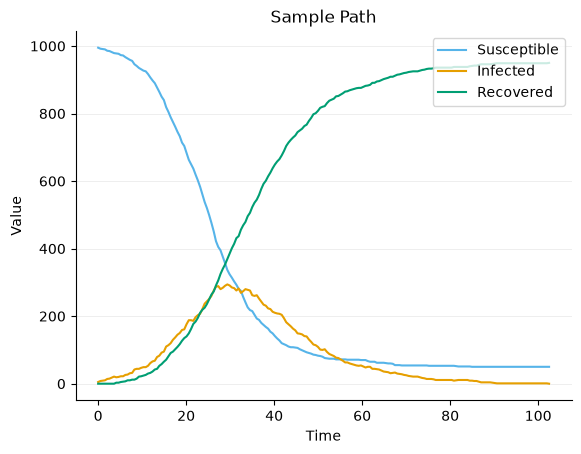

In [19]:
epidemic = SIR(population=1000, infection_rate=0.3, recovery_rate=0.1, initial_infected=5)
path = epidemic.draw()
path.S.plot(label="Susceptible")
path.I.plot(label="Infected")
path.R.plot(label="Recovered")

Because the model is stochastic, no two outbreaks are the same. Overlaying the infected curve from several independent runs shows how much the timing and size of the peak vary from outbreak to outbreak. (Here we pass an explicit `tmax` so the runs -- which each end at a different time -- share one time axis.)

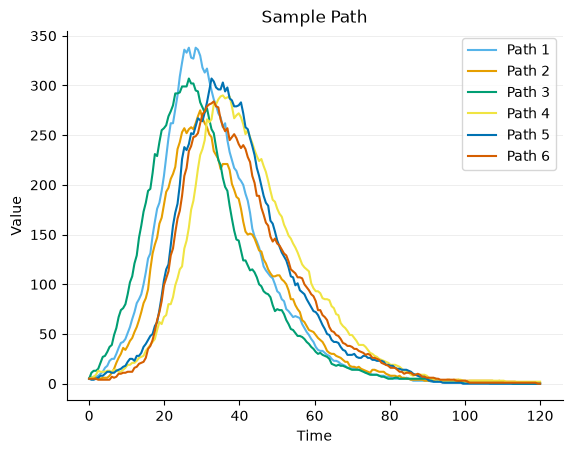

In [20]:
for _ in range(6):
    epidemic.draw().I.plot(tmin=0, tmax=120)

## The SEIR model

`SEIR(population, infection_rate, incubation_rate, recovery_rate, initial_infected)` adds an **Exposed** compartment for individuals who have been infected but are not yet infectious. Newly infected people become exposed, then turn infectious at rate `incubation_rate` (so `1 / incubation_rate` is the mean latent period), then recover. The extra stage delays and smooths the outbreak: the exposed curve leads the infectious one.

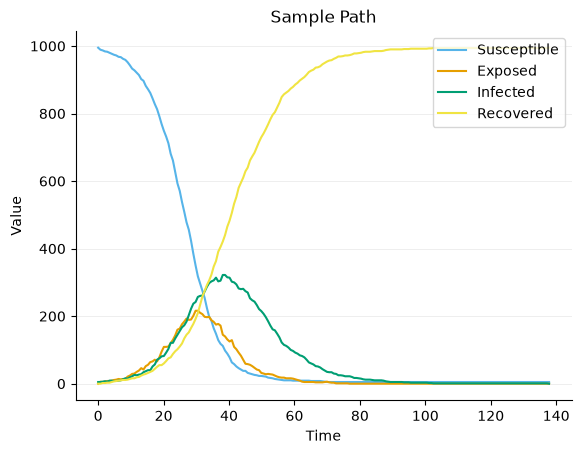

In [21]:
seir = SEIR(population=1000, infection_rate=0.5, incubation_rate=0.2,
            recovery_rate=0.1, initial_infected=5)
path = seir.draw()
path.S.plot(label="Susceptible")
path.E.plot(label="Exposed")
path.I.plot(label="Infected")
path.R.plot(label="Recovered")